In [11]:
import matplotlib.pyplot as plt 
import pandas as pd 

data_iso_40 = pd.read_csv("results_iso.csv")
data_iso_120 = pd.read_csv("results_iso_120.csv")
data_aniso_40 = pd.read_csv("results_aniso_40_200.csv")
data_aniso_40_200 = pd.read_csv("results_aniso_40_200_width.csv")
data_iso_120_width = pd.read_csv("results_iso_120_width.csv")

data_aniso_40_200

,Mesh,Pressure,Area_start,Area_end,Width_start,Width_end,Length_start,Length_end,Volume_1_start,Volume_2_start,Volume_1_end,Volume_2_end,Pore_width_start,Pore_width_end,Pore_height_start,Pore_height_end,Min_diameter_start,Min_diameter_end
0,1_2,0.01,40.56,47.62,4.90748,4.90748,14.314,14.314,3463.16,3596.71,3775.53,3897.55,4.9,5.8,11.0,11.0,4.9,5.8
1,1_2,0.11,40.56,58.85,4.90748,4.90748,14.314,14.314,3463.16,3596.71,3994.14,4148.22,4.9,6.8,11.0,11.7,4.9,6.8
2,1_2,0.21,40.56,64.25,4.90748,4.90748,14.314,14.314,3463.16,3596.71,4069.94,4250.61,4.9,7.2,11.0,12.0,4.9,7.2
3,1_2,0.31,40.56,68.40,4.90748,4.90748,14.314,14.314,3463.16,3596.71,4132.12,4337.66,4.9,7.4,11.0,12.2,4.9,7.4
4,1_2,0.41,40.56,71.97,4.90748,4.90748,14.314,14.314,3463.16,3596.71,4194.46,4408.93,4.9,7.7,11.0,12.4,4.9,7.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,3_7,0.51,21.96,41.90,0.00000,0.00000,0.000,0.000,3581.47,4073.96,4026.79,4847.10,3.0,5.3,10.4,10.8,3.0,5.3
176,3_7,0.61,21.96,43.54,0.00000,0.00000,0.000,0.000,3581.47,4073.96,4075.30,4916.35,3.0,5.4,10.4,10.9,3.0,5.4
177,3_7,0.71,21.96,45.11,0.00000,0.00000,0.000,0.000,3581.47,4073.96,4123.51,4983.98,3.0,5.6,10.4,11.0,3.0,5.6
178,3_7,0.81,21.96,46.48,0.00000,0.00000,0.000,0.000,3581.47,4073.96,4171.78,5050.74,3.0,5.7,10.4,11.1,3.0,5.7


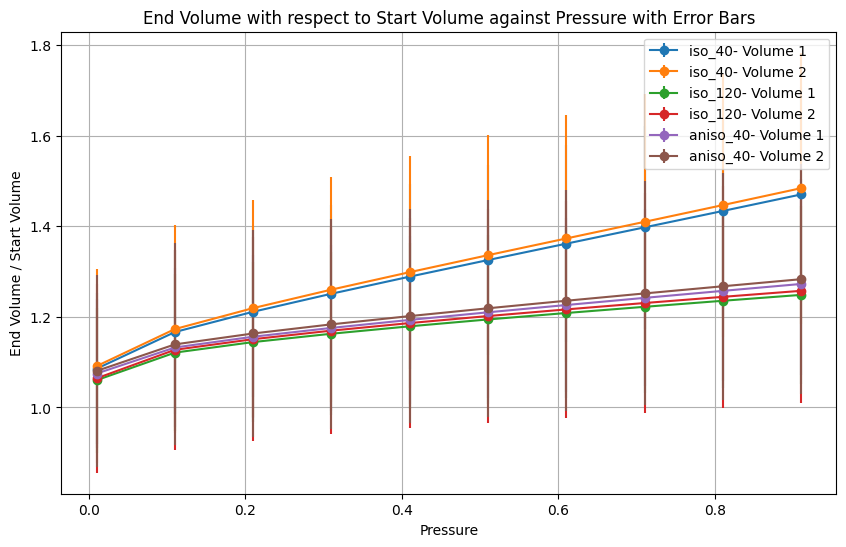

In [12]:
## For each dataset, plot the change in volume with respect to the initial volume, against the pressure. Include the error bars.

import pandas as pd
import matplotlib.pyplot as plt

# Load the datasets
data1 = data_iso_40
data2 = data_iso_120
data3 = data_aniso_40

dataset1 = "iso_40"
dataset2 = "iso_120"
dataset3 = "aniso_40"

def process_data(data):
    # Group by Pressure and calculate mean and standard deviation
    grouped = data.groupby('Pressure').agg({
        ' Volume_1_start': ['mean', 'std'],
        ' Volume_2_start': ['mean', 'std'],
        ' Volume_1_end': ['mean', 'std'],
        ' Volume_2_end': ['mean', 'std']
    }).reset_index()

    # Flatten the MultiIndex columns
    grouped.columns = ['Pressure', 'Volume_1_start_mean', 'Volume_1_start_std', 'Volume_2_start_mean', 'Volume_2_start_std', 'Volume_1_end_mean', 'Volume_1_end_std', 'Volume_2_end_mean', 'Volume_2_end_std']

    # Calculate the ratio of end volume to start volume
    grouped['Volume_1_ratio'] = grouped['Volume_1_end_mean'] / grouped['Volume_1_start_mean']
    grouped['Volume_2_ratio'] = grouped['Volume_2_end_mean'] / grouped['Volume_2_start_mean']

    # Calculate the error bars
    grouped['Volume_1_ratio_err'] = grouped['Volume_1_ratio'] * ((grouped['Volume_1_end_std'] / grouped['Volume_1_end_mean'])**2 + (grouped['Volume_1_start_std'] / grouped['Volume_1_start_mean'])**2)**0.5
    grouped['Volume_2_ratio_err'] = grouped['Volume_2_ratio'] * ((grouped['Volume_2_end_std'] / grouped['Volume_2_end_mean'])**2 + (grouped['Volume_2_start_std'] / grouped['Volume_2_start_mean'])**2)**0.5

    return grouped

# Process each dataset
grouped1 = process_data(data1)
grouped2 = process_data(data2)
grouped3 = process_data(data3)

# Plot the data with error bars
plt.figure(figsize=(10, 6))

plt.errorbar(grouped1['Pressure'], grouped1['Volume_1_ratio'], yerr=grouped1['Volume_1_ratio_err'], label= dataset1 + ' - Volume 1', fmt='-o')
plt.errorbar(grouped1['Pressure'], grouped1['Volume_2_ratio'], yerr=grouped1['Volume_2_ratio_err'], label= dataset1 + ' - Volume 2', fmt='-o')

plt.errorbar(grouped2['Pressure'], grouped2['Volume_1_ratio'], yerr=grouped2['Volume_1_ratio_err'], label= dataset2 + ' - Volume 1', fmt='-o')
plt.errorbar(grouped2['Pressure'], grouped2['Volume_2_ratio'], yerr=grouped2['Volume_2_ratio_err'], label= dataset2 + ' - Volume 2', fmt='-o')

plt.errorbar(grouped3['Pressure'], grouped3['Volume_1_ratio'], yerr=grouped3['Volume_1_ratio_err'], label= dataset3 + ' - Volume 1', fmt='-o')
plt.errorbar(grouped3['Pressure'], grouped3['Volume_2_ratio'], yerr=grouped3['Volume_2_ratio_err'], label= dataset3 + ' - Volume 2', fmt='-o')

plt.xlabel('Pressure')
plt.ylabel('End Volume / Start Volume')
plt.title('End Volume with respect to Start Volume against Pressure with Error Bars')
plt.legend()
plt.grid(True)
plt.show()



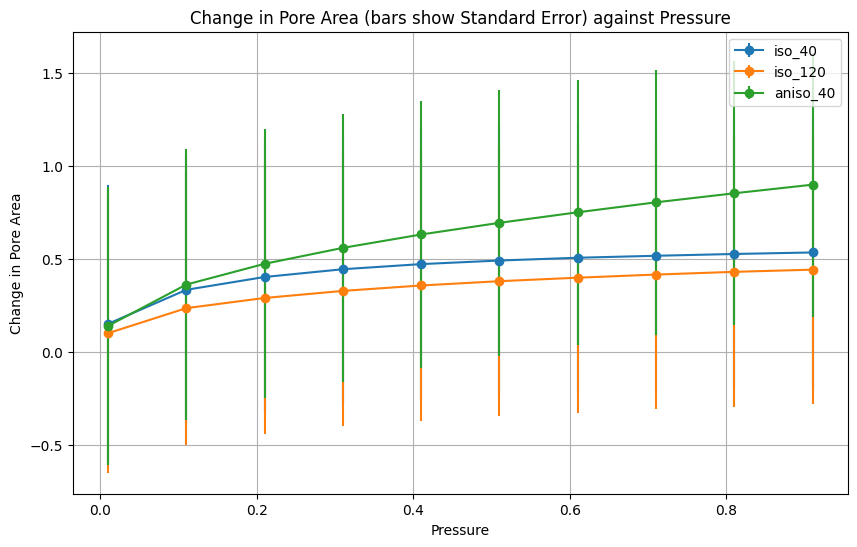

In [19]:
def process_data(data):
    # Group by Pressure and calculate mean and standard deviation
    grouped = data.groupby('Pressure').agg({
        'Area_start': ['mean', 'std'],
        'Area_end': ['mean', 'std']
    }).reset_index()

    # Flatten the MultiIndex columns
    grouped.columns = ['Pressure', 'Area_start_mean', 'Area_start_std', 'Area_end_mean', 'Area_end_std']

    # Calculate the change in pore area
    grouped['Area_change'] = (grouped['Area_end_mean'] - grouped['Area_start_mean']) / grouped['Area_start_mean']

    # Calculate the error bars for the relative change
    grouped['Area_change_err'] = ((grouped['Area_end_std'] / grouped['Area_end_mean'])**2 + 
                                  (grouped['Area_start_std'] / grouped['Area_start_mean'])**2)**0.5

    return grouped

# Process each dataset
grouped1 = process_data(data1)
grouped2 = process_data(data2)
grouped3 = process_data(data3)

# Plot the data with error bars
plt.figure(figsize=(10, 6))

plt.errorbar(grouped1['Pressure'], grouped1['Area_change'], yerr=grouped1['Area_change_err'], label=dataset1, fmt='-o')
plt.errorbar(grouped2['Pressure'], grouped2['Area_change'], yerr=grouped2['Area_change_err'], label=dataset2, fmt='-o')
plt.errorbar(grouped3['Pressure'], grouped3['Area_change'], yerr=grouped3['Area_change_err'], label=dataset3, fmt='-o')

plt.xlabel('Pressure')
plt.ylabel('Change in Pore Area')
plt.title('Change in Pore Area (bars show Standard Error) against Pressure')
plt.legend()
plt.grid(True)
plt.show()


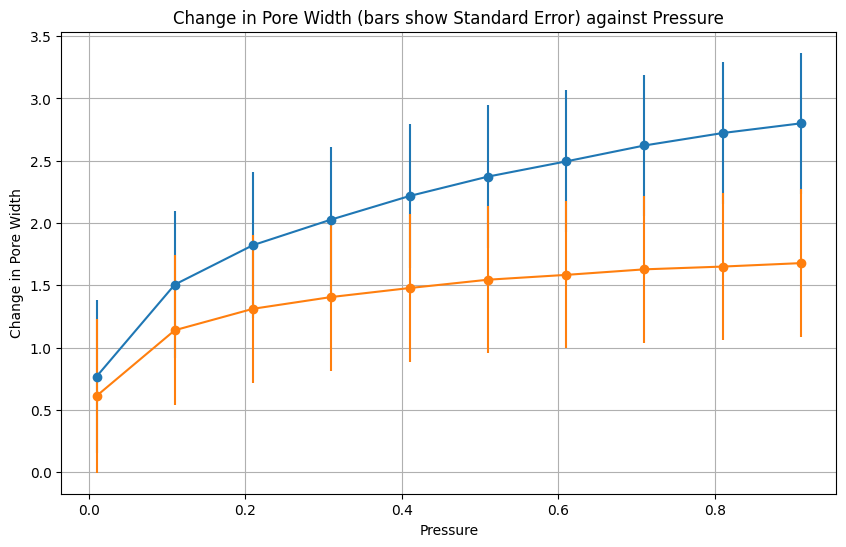

In [15]:
## For the data_aniso_40_200_width data set, plot the change in pore width

def process_data(data):
    # Group by Pressure and calculate mean and standard deviation
    grouped = data.groupby('Pressure').agg({
        'Pore_width_start': ['mean', 'std'],
        'Pore_width_end': ['mean', 'std']
    }).reset_index()

    # Flatten the MultiIndex columns
    grouped.columns = ['Pressure', 'Width_start_mean', 'Width_start_std', 'Width_end_mean', 'Width_end_std']

    # Calculate the change in pore width
    grouped['Width_change'] = (grouped['Width_end_mean'] - grouped['Width_start_mean'])

    # Calculate the error bars for the relative change
    grouped['Width_change_err'] = ((grouped['Width_end_std'] / grouped['Width_end_mean'])**2 + 
                                  (grouped['Width_start_std'] / grouped['Width_start_mean'])**2)**0.5

    return grouped

# Process the dataset
grouped = process_data(data_aniso_40_200)
grouped2 = process_data(data_iso_120_width)

# Plot the data with error bars
plt.figure(figsize=(10, 6))

plt.errorbar(grouped['Pressure'], grouped['Width_change'], yerr=grouped['Width_change_err'], fmt='-o')
plt.errorbar(grouped2['Pressure'], grouped2['Width_change'], yerr=grouped2['Width_change_err'], fmt='-o')

plt.xlabel('Pressure')

plt.ylabel('Change in Pore Width')

plt.title('Change in Pore Width (bars show Standard Error) against Pressure')

plt.grid(True)

plt.show()


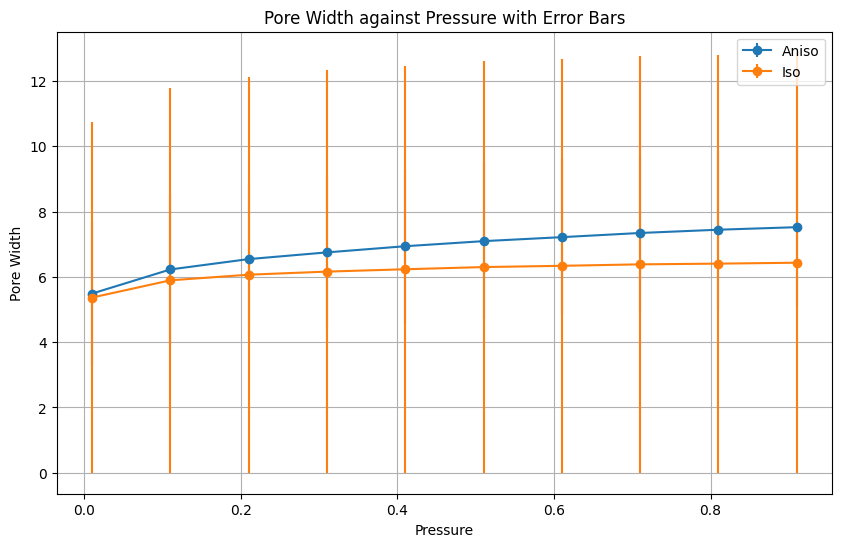

In [13]:
## Plot the absolute pore width against the pressure for the data_aniso_40_200_width data set

def process_data(data):
    # Group by Pressure and calculate mean and standard deviation
    grouped = data.groupby('Pressure').agg({
        'Pore_width_start': ['mean', 'std'],
        'Pore_width_end': ['mean', 'std']
    }).reset_index()

    # Flatten the MultiIndex columns
    grouped.columns = ['Pressure', 'Width_start_mean', 'Width_start_std', 'Width_end_mean', 'Width_end_std']

    return grouped

# Process the dataset
grouped = process_data(data_aniso_40_200)
grouped2 = process_data(data_iso_120_width)

# Plot the data with error bars
plt.figure(figsize=(10, 6))

plt.errorbar(grouped['Pressure'], grouped['Width_end_mean'], yerr=grouped['Width_end_std'], label='Aniso', fmt='-o')
plt.errorbar(grouped2['Pressure'], grouped2['Width_end_mean'], yerr=grouped2['Width_end_mean'], label='Iso', fmt='-o')

plt.xlabel('Pressure')
plt.ylabel('Pore Width')
plt.title('Pore Width against Pressure with Error Bars')
plt.legend()
plt.grid(True)
plt.show()